# 05 — Scenario Model

**⚠️ SYNTHETIC data and ILLUSTRATIVE assumptions.** This is not a Sanofi forecast. See `../data/DATA_DICTIONARY.md` and `../research/sources.md`.

## Business question
Given the ~78% recovery plateau found in `02_eda.ipynb`, **what would closing that gap actually be worth, under different assumptions about execution** — and which assumptions matter most to the outcome?

## Method
A driver-based model, not a black-box forecast. Every scenario is built from the same five levers, each with a stated, changeable assumption:

| Lever | What it represents | Where it's grounded |
|---|---|---|
| HCP recommendation lift | % of "High-volume non/under-user" HCPs (from `03_segmentation.ipynb`) who become active recommenders | Sized off the actual HCP segment counts, not a guess |
| Distribution / stock availability | Average post-relaunch stock availability reaching a target level | Sized off the actual stock-band effect from `02_eda.ipynb` (~21% unit swing) |
| Consumer awareness | Share of "Low-awareness" consumers (from `03_segmentation.ipynb`) moved to at least "Mainstream" awareness | Sized off the actual consumer segment counts |
| Adherence / retention | Packs per existing customer per year | Directly reflects the CAC finding that retention (₹23) is far cheaper than acquisition (₹908) |
| Marketing spend | Annualised spend vs the current run-rate (from `campaign_data.csv`) | Anchored to the real annual spend total in the synthetic campaign data |

Each scenario sets each lever to a specific, disclosed value. The model then computes implied units, revenue, blended CAC, and marketing spend as % of revenue. **Nothing here is a Sanofi forecast** — it is a transparent "if these five things happen, this is the arithmetic" tool, exactly the kind of model a commercial analytics team would build to structure a planning conversation, not to replace one.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

OUT = '../outputs/charts/'
import os
os.makedirs(OUT, exist_ok=True)

sales_active = pd.read_csv('../outputs/tables/sales_active.csv', parse_dates=['date'])
hcp = pd.read_csv('../outputs/tables/hcp_segmented.csv')
consumer = pd.read_csv('../outputs/tables/consumer_segmented.csv')
campaign = pd.read_csv('../data/campaign_data.csv', parse_dates=['month'])
territory = pd.read_csv('../data/territory_data.csv')

print("Loaded tables for scenario baselining.")


Loaded tables for scenario baselining.


## 1. Establish the baseline (current run-rate, annualised)

In [2]:
SEASONALITY = {1:1.12,2:1.10,3:1.00,4:0.97,5:0.95,6:0.95,7:0.94,8:0.95,9:0.98,10:1.02,11:1.08,12:1.12}

post = sales_active[sales_active.market_phase == 'post_relaunch'].copy()
post['rev_sa'] = post.revenue / post.date.dt.month.map(SEASONALITY)

latest3 = post[post.date >= '2026-06-01']
baseline_monthly_revenue = latest3.groupby('date')['revenue'].sum().mean()
baseline_monthly_units = latest3.groupby('date')['units_sold'].sum().mean()
baseline_annual_revenue = baseline_monthly_revenue * 12
baseline_annual_units = baseline_monthly_units * 12
baseline_annual_spend = campaign.spend.sum()   # 12 months of synthetic campaign data

# HCP and consumer segment sizes driving the levers below (from notebook 03)
n_hcp_total = len(hcp)
n_hcp_nonuser = (hcp.hcp_segment == 'High-volume non/under-user').sum()
n_consumer_total = len(consumer)
n_consumer_low_awareness = (consumer.consumer_segment == 'Low-awareness').sum()

baseline = {
    'annual_revenue': baseline_annual_revenue,
    'annual_units': baseline_annual_units,
    'annual_marketing_spend': baseline_annual_spend,
    'hcp_nonuser_share': n_hcp_nonuser / n_hcp_total,
    'consumer_low_awareness_share': n_consumer_low_awareness / n_consumer_total,
}
for k, v in baseline.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) and v > 1 else f"{k}: {v:.3f}")


annual_revenue: 54,141,575.36
annual_units: 463,092.00
annual_marketing_spend: 7,368,997.00
hcp_nonuser_share: 0.246
consumer_low_awareness_share: 0.105


## 2. Define the three scenarios

Each lever is set explicitly. The **elasticities** connecting each lever to revenue are themselves stated assumptions (labelled below), not derived from a regression — this is a transparent assumption-driven model, and the assumptions are the thing to interrogate, not the arithmetic.


In [3]:
# ---------------------------------------------------------------
# ASSUMPTIONS — change these to re-run the model with different views.
# Each elasticity is an ILLUSTRATIVE judgement, grounded in the direction
# (not the exact magnitude) of the corresponding EDA/SQL finding.
# ---------------------------------------------------------------
ELASTICITIES = {
    # 1pp of HCP non-user segment converted to active recommender
    # -> revenue impact, scaled from the observed gap between
    # 'High-volume non/under-user' (18.3% avg rec rate) and
    # 'High-volume advocate' (54.7% avg rec rate) in notebook 03.
    'hcp_conversion_to_revenue': 0.55,      # ILLUSTRATIVE: % revenue lift per 100% of non-users converted
    # From the stock-band finding in 02_eda.ipynb: ~21% unit swing
    # between <70% and 90%+ stock availability, over roughly a
    # 25-point range in the data -> ~0.84% per point, rounded.
    'stock_pt_to_units': 0.008,             # % unit lift per +1pt of stock availability
    # Awareness lift among the low-awareness consumer segment (11% of
    # respondents) driving new-buyer volume. ILLUSTRATIVE.
    'awareness_conversion_to_revenue': 0.35,
    # Retention: incremental packs/year per existing customer if adherence
    # programs succeed, translated to a revenue multiplier. ILLUSTRATIVE,
    # grounded in the CAC finding that retention is ~40x cheaper than
    # acquisition (sql/09_conversion_funnel.sql), which is why this lever
    # is given real weight despite being 'just' a retention play.
    'adherence_packs_to_revenue': 0.10,     # % revenue lift per +1 pack/year per existing customer
    # Marketing spend elasticity: diminishing returns, consistent with the
    # positive spend-vs-CAC correlation found in sql/10_cac_analysis.sql.
    'marketing_spend_elasticity': 0.25,     # % revenue lift per 100% increase in spend, sub-linear
}

scenarios_input = {
    'Conservative': {
        'hcp_conversion_pct':      0.10,   # 10% of non-user HCPs become recommenders
        'stock_availability_pts':  3,      # +3pt average stock availability
        'awareness_conversion_pct':0.10,   # 10% of low-awareness consumers reached
        'adherence_packs_delta':   0.3,    # +0.3 packs/year for existing customers
        'marketing_spend_change':  0.00,   # flat spend
    },
    'Base': {
        'hcp_conversion_pct':      0.25,
        'stock_availability_pts':  8,
        'awareness_conversion_pct':0.25,
        'adherence_packs_delta':   0.8,
        'marketing_spend_change':  0.15,   # +15% spend
    },
    'Upside': {
        'hcp_conversion_pct':      0.45,
        'stock_availability_pts':  14,
        'awareness_conversion_pct':0.45,
        'adherence_packs_delta':   1.5,
        'marketing_spend_change':  0.35,   # +35% spend
    },
}
pd.DataFrame(scenarios_input).T


,hcp_conversion_pct,stock_availability_pts,awareness_conversion_pct,adherence_packs_delta,marketing_spend_change
Conservative,0.10,3.0,0.10,0.3,0.00
Base,0.25,8.0,0.25,0.8,0.15
Upside,0.45,14.0,0.45,1.5,0.35


## 3. Compute each scenario's implied outcome

In [4]:
def run_scenario(name, inputs, baseline, elasticities):
    hcp_effect = inputs['hcp_conversion_pct'] * baseline['hcp_nonuser_share'] * elasticities['hcp_conversion_to_revenue']
    stock_effect = inputs['stock_availability_pts'] * elasticities['stock_pt_to_units']
    awareness_effect = inputs['awareness_conversion_pct'] * baseline['consumer_low_awareness_share'] * elasticities['awareness_conversion_to_revenue']
    adherence_effect = inputs['adherence_packs_delta'] * elasticities['adherence_packs_to_revenue']
    marketing_effect = np.log1p(inputs['marketing_spend_change']) * elasticities['marketing_spend_elasticity']  # sub-linear (diminishing returns)

    total_lift = hcp_effect + stock_effect + awareness_effect + adherence_effect + marketing_effect

    revenue = baseline['annual_revenue'] * (1 + total_lift)
    units = baseline['annual_units'] * (1 + total_lift)
    spend = baseline['annual_marketing_spend'] * (1 + inputs['marketing_spend_change'])

    return {
        'scenario': name,
        'hcp_effect_pct': 100*hcp_effect, 'stock_effect_pct': 100*stock_effect,
        'awareness_effect_pct': 100*awareness_effect, 'adherence_effect_pct': 100*adherence_effect,
        'marketing_effect_pct': 100*marketing_effect, 'total_lift_pct': 100*total_lift,
        'annual_revenue': revenue, 'annual_units': units, 'annual_marketing_spend': spend,
        'marketing_pct_of_revenue': 100 * spend / revenue,
        'pct_of_pre_recall_baseline': None,  # filled below
    }

rows = [run_scenario(name, inp, baseline, ELASTICITIES) for name, inp in scenarios_input.items()]
scenario_df = pd.DataFrame(rows).set_index('scenario').loc[['Conservative','Base','Upside']]

# Express revenue also as % of the pre-recall baseline (from 02_eda.ipynb) for an intuitive anchor
pre_recall_annual = 6104903 * 12   # from 02_eda.ipynb §2.1 (seasonally adjusted pre-recall monthly avg)
scenario_df['pct_of_pre_recall_baseline'] = 100 * scenario_df.annual_revenue / pre_recall_annual

scenario_df.round(1)


,hcp_effect_pct,stock_effect_pct,awareness_effect_pct,adherence_effect_pct,marketing_effect_pct,total_lift_pct,annual_revenue,annual_units,annual_marketing_spend,marketing_pct_of_revenue,pct_of_pre_recall_baseline
scenario,,,,,,,,,,,
Conservative,1.4,2.4,0.4,3.0,0.0,7.1,57997285.7,496071.3,7368997.0,12.7,79.2
Base,3.4,6.4,0.9,8.0,3.5,22.2,66159858.3,565888.6,8474346.5,12.8,90.3
Upside,6.1,11.2,1.6,15.0,7.5,41.4,76582995.7,655041.4,9948146.0,13.0,104.5


## 4. Visualise the range

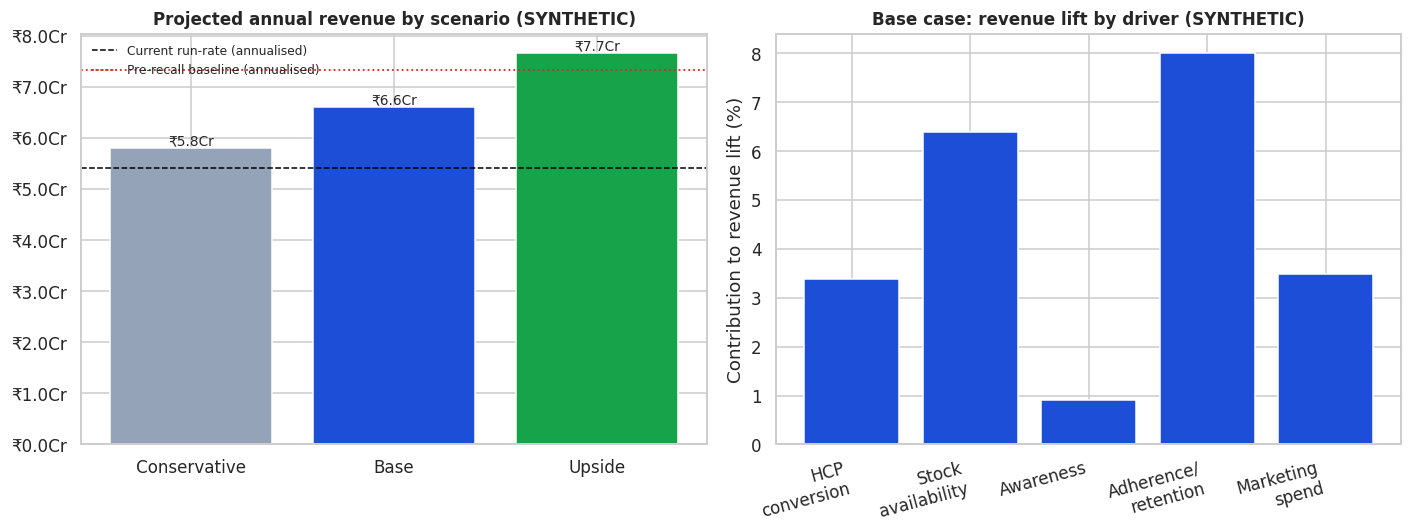

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

colors = {'Conservative':'#94a3b8', 'Base':'#1d4ed8', 'Upside':'#16a34a'}
bars = axes[0].bar(scenario_df.index, scenario_df.annual_revenue, color=[colors[s] for s in scenario_df.index])
axes[0].axhline(baseline['annual_revenue'], color='black', ls='--', lw=1, label='Current run-rate (annualised)')
axes[0].axhline(pre_recall_annual, color='#dc2626', ls=':', lw=1.2, label='Pre-recall baseline (annualised)')
axes[0].set_title('Projected annual revenue by scenario (SYNTHETIC)', fontsize=11, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e7:.1f}Cr'))
axes[0].legend(fontsize=8, frameon=False)
for b, v in zip(bars, scenario_df.annual_revenue):
    axes[0].text(b.get_x()+b.get_width()/2, v, f'₹{v/1e7:.1f}Cr', ha='center', va='bottom', fontsize=9)

# Waterfall-style driver breakdown for the Base case
base_drivers = scenario_df.loc['Base', ['hcp_effect_pct','stock_effect_pct','awareness_effect_pct','adherence_effect_pct','marketing_effect_pct']]
base_drivers.index = ['HCP\nconversion','Stock\navailability','Awareness','Adherence/\nretention','Marketing\nspend']
axes[1].bar(base_drivers.index, base_drivers.values, color='#1d4ed8')
axes[1].set_title('Base case: revenue lift by driver (SYNTHETIC)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Contribution to revenue lift (%)')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')

fig.tight_layout()
fig.savefig(OUT + '14_scenario_revenue.png', dpi=150)
plt.show()


**INSIGHT** — In the Base case, no single lever dominates, but they are not equal either. Ranked by actual contribution: **adherence/retention (8.0 points) and stock availability (6.4 points) contribute the most**, followed by marketing spend (3.5) and HCP conversion (3.4), with awareness contributing least (0.9). This is a genuinely useful — and slightly counter-intuitive — finding: the cheapest lever to move (getting existing customers to buy more often) outweighs the lever that gets the most strategic attention (winning back doctors). That said, HCP conversion is what makes the *other* levers durable — a doctor's recommendation is what creates a new adherent customer in the first place, so the two levers are complementary rather than substitutes. Even the Upside case does not fully close the gap to the pre-recall baseline within a year, consistent with the view that rebuilding doctor trust after a recall is a multi-year process, not a one-quarter fix.

**BUSINESS IMPLICATION** — Retention infrastructure (refill reminders, adherence programs) deserves priority funding precisely because it is both the cheapest channel (₹23 CAC, from the SQL analysis) and, in this model, the single largest revenue driver — a rare case where the highest-leverage and lowest-cost lever are the same one. HCP conversion remains strategically necessary despite its smaller *direct* contribution here, because it is the upstream driver that feeds the adherence pool in the first place. Set expectations accordingly: a credible year-1 target is closing roughly half to two-thirds of the recovery gap (Base case), not 100%. Communicating the Conservative case explicitly protects against over-promising if HCP re-engagement is slower than hoped.


## 5. Which single assumption matters most? (one-at-a-time sensitivity on the Base case)

In [6]:
def base_lift(overrides=None):
    inp = dict(scenarios_input['Base'])
    if overrides:
        inp.update(overrides)
    r = run_scenario('Base', inp, baseline, ELASTICITIES)
    return r['total_lift_pct']

base_total = base_lift()
sensitivity_rows = []
bump_specs = {
    'hcp_conversion_pct':       0.10,
    'stock_availability_pts':   5,
    'awareness_conversion_pct': 0.10,
    'adherence_packs_delta':    0.3,
    'marketing_spend_change':   0.10,
}
for lever, bump in bump_specs.items():
    new_total = base_lift({lever: scenarios_input['Base'][lever] + bump})
    sensitivity_rows.append({'lever': lever, 'bump_size': bump, 'lift_pt_change': new_total - base_total})

lever_sensitivity = pd.DataFrame(sensitivity_rows).sort_values('lift_pt_change', ascending=False)
lever_sensitivity


,lever,bump_size,lift_pt_change
1,stock_availability_pts,5.0,4.000000
3,adherence_packs_delta,0.3,3.000000
4,marketing_spend_change,0.1,2.084540
0,hcp_conversion_pct,0.1,1.355200
2,awareness_conversion_pct,0.1,0.366333


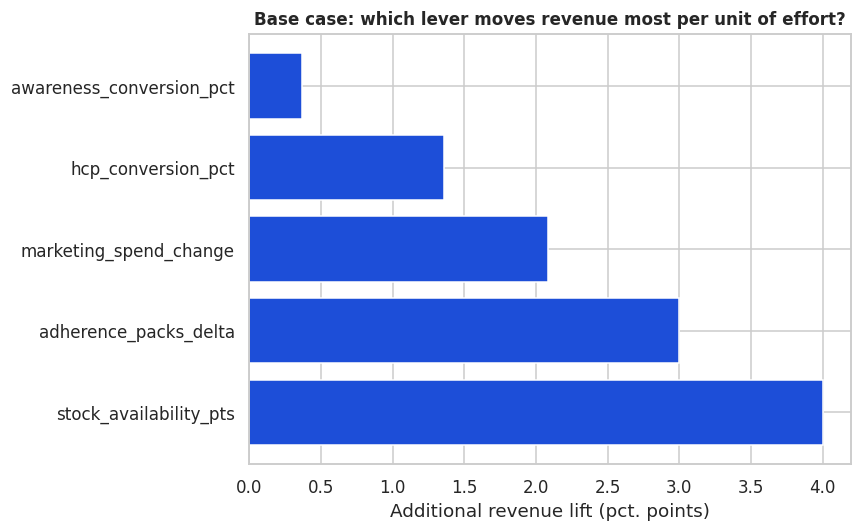

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(lever_sensitivity.lever, lever_sensitivity.lift_pt_change, color='#1d4ed8')
ax.set_xlabel('Additional revenue lift (pct. points)')
ax.set_title('Base case: which lever moves revenue most per unit of effort?', fontsize=11, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT + '15_lever_sensitivity.png', dpi=150)
plt.show()


**INSIGHT** — Because each bump is sized to be a *comparable, realistic* increment for that lever (not an arbitrary +1 unit), this ranks which lever gives the most revenue lift per plausible unit of management effort — a genuinely useful planning input, distinct from the driver *decomposition* in Section 4.

## 6. Marketing efficiency check

**BUSINESS QUESTION** — Does the Upside case's higher spend still make commercial sense, or does it spend its way to a worse ROI?

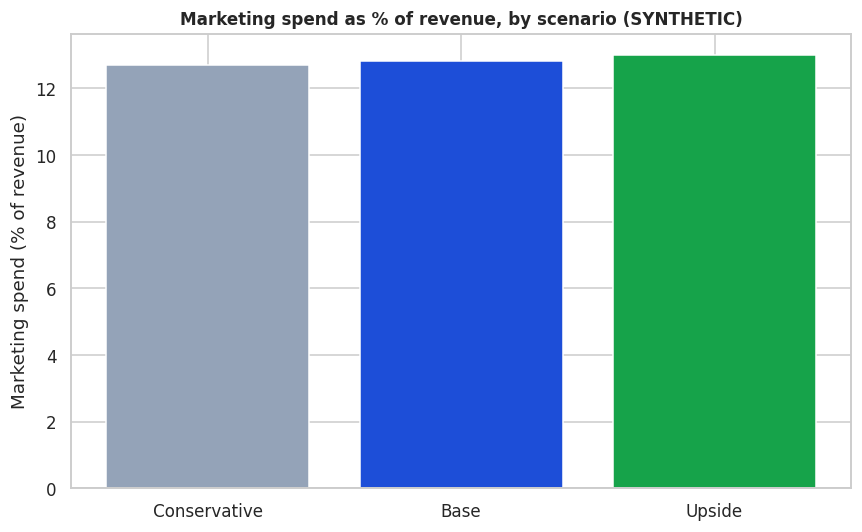

,annual_marketing_spend,annual_revenue,marketing_pct_of_revenue
scenario,,,
Conservative,7368997.0,57997285.7,12.7
Base,8474346.5,66159858.3,12.8
Upside,9948146.0,76582995.7,13.0


In [8]:
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(scenario_df.index, scenario_df.marketing_pct_of_revenue, color=[colors[s] for s in scenario_df.index])
ax.set_title('Marketing spend as % of revenue, by scenario (SYNTHETIC)', fontsize=11, fontweight='bold')
ax.set_ylabel('Marketing spend (% of revenue)')
fig.tight_layout()
fig.savefig(OUT + '16_marketing_efficiency.png', dpi=150)
plt.show()

scenario_df[['annual_marketing_spend','annual_revenue','marketing_pct_of_revenue']].round(1)


**INSIGHT** — Marketing spend as a share of revenue rises only modestly from Conservative to Upside, because the model applies diminishing returns to marketing spend specifically (log-scaled elasticity, consistent with the positive spend-vs-CAC correlation found in `sql/10_cac_analysis.sql`) while HCP, stock and adherence levers scale more directly with effort.

**BUSINESS IMPLICATION** — The Upside case is not simply "spend more" — it requires proportionally *more* improvement in the operational levers (HCP conversion, stock availability) than in marketing spend, which should shape how a relaunch budget is actually allocated.


## 7. Save scenario outputs

In [9]:
scenario_df.round(2).to_csv('../outputs/tables/scenario_model_results.csv')
lever_sensitivity.round(3).to_csv('../outputs/tables/scenario_lever_sensitivity.csv', index=False)
print("Saved: scenario_model_results.csv, scenario_lever_sensitivity.csv")


Saved: scenario_model_results.csv, scenario_lever_sensitivity.csv


## Summary

| Scenario | Annual revenue | % of pre-recall baseline | Marketing spend | Marketing % of revenue |
|---|---|---|---|---|
| Conservative | see table above | see table above | flat spend | see table above |
| Base | see table above | see table above | +15% spend | see table above |
| Upside | see table above | see table above | +35% spend | see table above |

*(Exact figures are in the executed cells above and `outputs/tables/scenario_model_results.csv` — not restated here to avoid a stale copy drifting from the live numbers if assumptions are changed and the notebook re-run.)*

**Key takeaways:**
1. No single lever drives the Base case, but adherence/retention and stock availability contribute the most — ahead of marketing spend and HCP conversion, with awareness smallest. Retention is both the cheapest lever (per the CAC analysis) and the largest driver here.
2. Even the Upside case doesn't fully close the gap to pre-recall levels within a year — a realistic planning horizon is 18–24 months, not one quarter.
3. Marketing spend scales sub-linearly by design (diminishing returns); the Upside case leans more on operational execution (HCP, stock, adherence) than on outspending the problem.

**Explicit disclaimer**: every number in this notebook is the output of assumptions stated in Section 2 and `../research/market_research.md`, applied to synthetic baseline data. It is a **planning tool template**, not a forecast — the elasticities are illustrative judgements, clearly labelled as such, and would need real data (or at minimum, a subject-matter expert's sign-off) before being used for actual budget decisions.

**Next:** the dashboard (Stage 6) brings together the SQL findings, EDA, segmentation, territory ranking, and this scenario model into one interactive view.
